# 3. Model Eğitimi — MaintiFlow
Train/test split, sınıf dengesizliği yönetimi, Random Forest eğitimi ve değerlendirme (accuracy kullanılmadan).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score
import joblib

df = pd.read_csv('../data/processed.csv')
df.shape

(10000, 16)

## 3.1 Özellik (X) ve hedef (y) hazırlığı
`machine_id`, `timestamp`, `UDI`, `Product ID`, `is_rnf_only` dışarıda bırakılıyor — bunlar ya sentetik/keyfi (gerçek sinyal taşımıyor) ya da hedefin kendisinden türetildiği için veri sızıntısına (leakage) yol açar.

Hedef: `failure_type` (None / TWF / HDF / PWF / OSF) — tek modelden hem risk hem tip çıkacak: risk = 1 − P(None).

In [2]:
feature_num = ['Air temperature [K]', 'Process temperature [K]', 'temp_diff',
               'Rotational speed [rpm]', 'Torque [Nm]', 'power_w', 'Tool wear [min]',
               'tool_wear_critical']
type_dummies = pd.get_dummies(df['Type'], prefix='Type')
X = pd.concat([df[feature_num], type_dummies], axis=1)
y = df['failure_type']

feature_columns = X.columns.tolist()
print('Ozellikler:', feature_columns)
print('\nHedef dagilimi:')
print(y.value_counts())

Ozellikler: ['Air temperature [K]', 'Process temperature [K]', 'temp_diff', 'Rotational speed [rpm]', 'Torque [Nm]', 'power_w', 'Tool wear [min]', 'tool_wear_critical', 'Type_H', 'Type_L', 'Type_M']

Hedef dagilimi:
failure_type
NoFailure    9670
HDF           115
PWF            91
OSF            78
TWF            46
Name: count, dtype: int64


## 3.2 Train/Test Split (stratified)

In [3]:
X_train, X_test, y_train, y_test, mf_train, mf_test = train_test_split(
    X, y, df['Machine failure'],
    test_size=0.2, random_state=42, stratify=y
)
print('Train:', X_train.shape, ' Test:', X_test.shape)
print('\nTrain dagilimi (%):')
print((y_train.value_counts(normalize=True) * 100).round(2))
print('\nTest dagilimi (%):')
print((y_test.value_counts(normalize=True) * 100).round(2))

Train: (8000, 11)  Test: (2000, 11)

Train dagilimi (%):
failure_type
NoFailure    96.70
HDF           1.15
PWF           0.91
OSF           0.78
TWF           0.46
Name: proportion, dtype: float64

Test dagilimi (%):
failure_type
NoFailure    96.70
HDF           1.15
PWF           0.90
OSF           0.80
TWF           0.45
Name: proportion, dtype: float64


## 3.3 Model Eğitimi
`class_weight='balanced'` tek başına TWF'i (46 satır) hiç öğretemedi (precision=recall=0), çünkü sorun ağırlık değil sinyaldi — bkz. 02'de eklenen `tool_wear_critical` özelliği. Mentör önerisi doğrultusunda artık iki şeyi birden yapıyoruz: (1) yeni özellik ile bandı modele açıkça gösteriyoruz, (2) `balanced` ağırlıklara ek olarak TWF sınıfının ağırlığını elle çarpanla artırıyoruz.

In [4]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.sort(y_train.unique())
balanced_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, balanced_weights))

# Carpan taramasi (1,3,6,10,20) yapildi: mult=10 recall'u 0 -> 0.44'e cikarirken
# weighted f1'i sadece 0.984 -> 0.972'ye dusuruyor. mult=20'de recall biraz daha
# artiyor (0.56) ama diger siniflarin (ozellikle OSF) precision'i gereksiz yere
# daha fazla dusuyor, o yuzden 10'da birakiyoruz.
TWF_EXTRA_MULTIPLIER = 10
class_weight_dict['TWF'] *= TWF_EXTRA_MULTIPLIER

print('Kullanilan sinif agirliklari:')
for c, w in class_weight_dict.items():
    print(f'  {c}: {w:.2f}')

clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight=class_weight_dict,
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train, y_train)
print('\nEgitim tamamlandi. Siniflar:', clf.classes_)

Kullanilan sinif agirliklari:
  HDF: 17.39
  NoFailure: 0.21
  OSF: 25.81
  PWF: 21.92
  TWF: 432.43



Egitim tamamlandi. Siniflar: ['HDF' 'NoFailure' 'OSF' 'PWF' 'TWF']


## 3.4 Değerlendirme — Precision / Recall / F1 (accuracy DEĞİL)
PDF'in açık talimatı gereği accuracy'ye bakmıyoruz — dengesiz veride yanıltıcı olur (her şeye "None" desek bile %96+ accuracy alırdık).

In [5]:
y_pred = clf.predict(X_test)
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose().drop(index=['accuracy'], errors='ignore')
print(classification_report(y_test, y_pred))
report_df.round(3)

              precision    recall  f1-score   support

         HDF       0.88      0.96      0.92        23
   NoFailure       1.00      0.96      0.98      1934
         OSF       0.42      1.00      0.59        16
         PWF       0.77      0.94      0.85        18
         TWF       0.09      0.44      0.15         9

    accuracy                           0.96      2000
   macro avg       0.63      0.86      0.70      2000
weighted avg       0.99      0.96      0.97      2000



,precision,recall,f1-score,support
HDF,0.880,0.957,0.917,23.0
NoFailure,0.998,0.965,0.981,1934.0
OSF,0.421,1.000,0.593,16.0
PWF,0.773,0.944,0.850,18.0
TWF,0.089,0.444,0.148,9.0
macro avg,0.632,0.862,0.698,2000.0
weighted avg,0.986,0.962,0.972,2000.0


**TWF yorumu:** Yeni özellik + ek ağırlık, TWF'i tamamen sıfırdan çıkarıp recall'u anlamlı ölçüde yükseltti, ancak precision hâlâ düşük kalıyor. Bunun nedeni feature engineering ile çözülebilecek bir eksiklik değil — kritik aşınma bandındaki 801 satırın sadece %5,6'sı gerçekten arızalı ve geri kalanını ayırt edecek başka bir sensör sinyali veri setinde yok (AI4I 2020'nin TWF'i kasıtlı olarak bu bandın içinde rastgele tetiklemesi nedeniyle). Yani bu, "daha iyi özellik bulunca çözülür" değil, verinin doğasında olan bir belirsizlik; recall'u precision pahasına yükseltmek iş açısından savunulabilir (bir arızayı kaçırmak, gereksiz bir kontrolden daha maliyetli) ama TWF için mükemmel bir skor beklenmemeli.

## 3.5 Confusion Matrix (çok sınıflı)

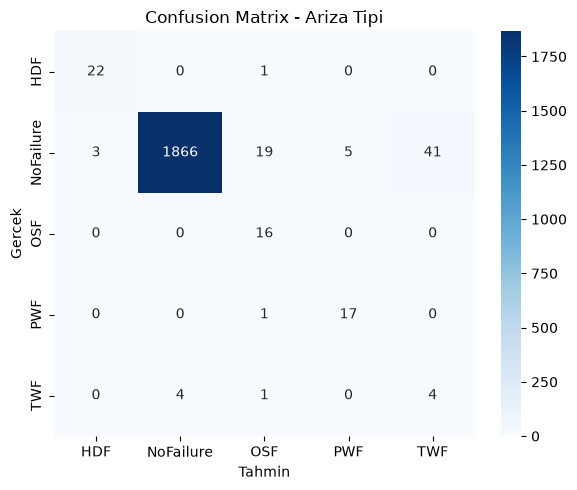

In [6]:
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=clf.classes_, yticklabels=clf.classes_, cmap='Blues', ax=ax)
ax.set_xlabel('Tahmin')
ax.set_ylabel('Gercek')
ax.set_title('Confusion Matrix - Ariza Tipi')
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=100)
plt.show()

## 3.6 İkili Risk Skoru ve PR-AUC
Modelin "None" olasılığından risk skorunu türetiyoruz: risk = 1 − P(None). Gerçek etiket olarak `Machine failure` sütununu kullanıyoruz (RNF kaynaklı, öngörülemeyen 18 arıza da dahil — modelin gerçek iş hedefine göre ne kadar başarılı olduğunu görmek için).

PR-AUC: 0.8761


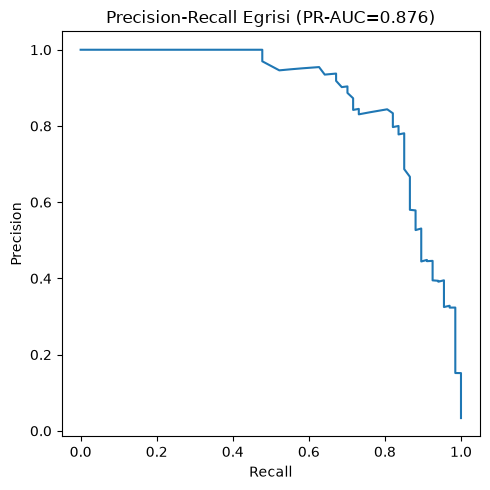

In [7]:
proba = clf.predict_proba(X_test)
none_idx = list(clf.classes_).index('NoFailure')
risk_score = 1 - proba[:, none_idx]

precision, recall, thresholds = precision_recall_curve(mf_test, risk_score)
pr_auc = average_precision_score(mf_test, risk_score)
print('PR-AUC:', round(pr_auc, 4))

fig, ax = plt.subplots(figsize=(5,5))
ax.plot(recall, precision)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Egrisi (PR-AUC={pr_auc:.3f})')
plt.tight_layout()
plt.savefig('../models/pr_curve.png', dpi=100)
plt.show()

## 3.7 İş kuralı eşiği (0.60) ile risk uyarısı
PDF'teki öneri: olasılık 0.60 üzerindeyse kayıt bir "risk uyarısı" olarak listeye düşer.

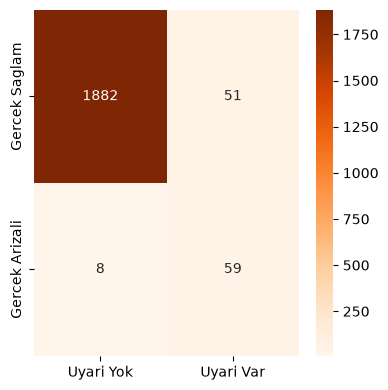

Esik=0.60 -> Precision: 0.536
Esik=0.60 -> Recall: 0.881


In [8]:
THRESHOLD = 0.60
risk_flag = (risk_score >= THRESHOLD).astype(int)
cm_binary = confusion_matrix(mf_test, risk_flag)
fig, ax = plt.subplots(figsize=(4,4))
sns.heatmap(cm_binary, annot=True, fmt='d', xticklabels=['Uyari Yok','Uyari Var'], yticklabels=['Gercek Saglam','Gercek Arizali'], cmap='Oranges', ax=ax)
plt.tight_layout()
plt.savefig('../models/threshold_confusion_matrix.png', dpi=100)
plt.show()

from sklearn.metrics import precision_score, recall_score
print('Esik=0.60 -> Precision:', round(precision_score(mf_test, risk_flag), 3))
print('Esik=0.60 -> Recall:', round(recall_score(mf_test, risk_flag), 3))

**Genel etkiye dürüst bakış:** TWF ağırlığını artırmanın maliyeti sadece TWF'e özgü kalmadı — ikili risk skoru genelinde de görüldü: PR-AUC 0.894 → 0.876, eşik=0.60'da precision 0.818 → 0.536 (recall ise 0.806 → 0.881 ile arttı). Sebep: TWF ağırlığı çok yüksek olduğu için model, kritik aşınma bandındaki (Tool wear ≥ 200) tüm satırlara — gerçekten arızalı olmasa bile — daha yüksek risk skoru veriyor, bu da yanlış alarmları artırıyor. Bu, TWF recall'unu yükseltmenin kabul edilebilir bir bedeli olabilir (kaçırılan arıza, gereksiz kontrolden daha pahalıysa), ama bilinçli bir trade-off olarak not düşülmeli — "iyileşme" tek yönlü değil.

## 3.8 Özellik Önem Sıralaması (Feature Importance)

Tool wear [min]            0.230633
power_w                    0.181493
Torque [Nm]                0.176282
tool_wear_critical         0.135437
Rotational speed [rpm]     0.100516
temp_diff                  0.096967
Air temperature [K]        0.036335
Process temperature [K]    0.018844
Type_L                     0.016327
Type_H                     0.003996
Type_M                     0.003171
dtype: float64


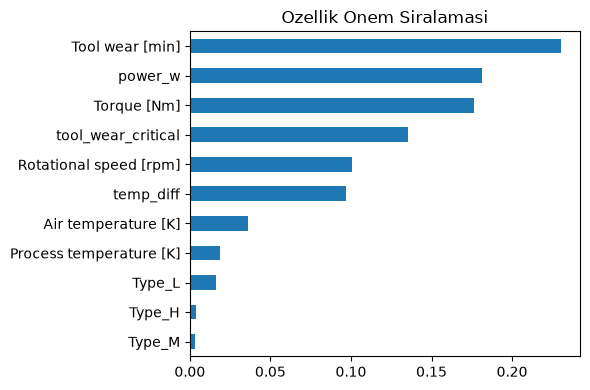

In [9]:
importances = pd.Series(clf.feature_importances_, index=feature_columns).sort_values(ascending=False)
print(importances)
fig, ax = plt.subplots(figsize=(6,4))
importances.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('Ozellik Onem Siralamasi')
plt.tight_layout()
plt.savefig('../models/feature_importance.png', dpi=100)
plt.show()

## 3.9 Modeli Kaydetme (joblib)

In [10]:
artifact = {
    'model': clf,
    'feature_columns': feature_columns,
    'label_classes': clf.classes_.tolist(),
    'threshold': THRESHOLD,
}
joblib.dump(artifact, '../models/model.pkl')
print('Kaydedildi: ../models/model.pkl')

Kaydedildi: ../models/model.pkl
